# Liquidity & E-Trading Analyst Test A

This exercise is intended to assess how you approach trading data analysis in a practical setting.

Please explain your reasoning clearly and state any assumptions you make where relevant.

There is no single correct solution. We are interested not only in the final output, but also in how you structure the problem, validate the data, make decisions, and communicate your findings.

Where the data is incomplete or ambiguous, use reasonable assumptions and document them.

Clarity of thought and quality of judgement matter as much as the results themselves.

Liquidity & E‑Trading Analyst Test A

**Candidate**: Anaswar T  
**Date**: 22 April 2026  
**Environment**: Python (VS Code, Jupyter)
**Objective**: Clean a tick-level trading dataset and perform basic analytics to
support liquidity and e-trading insights.

### Libraries

I use standard Python data and plotting libraries for this exercise: pandas/numpy
for data manipulation and matplotlib/seaborn for basic visualisation.

This notebook contains my step‑by‑step approach to the coding exercise.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Cleaning

Load the dataset and perform any cleaning steps you consider necessary.

Clearly document:

- what issues you identified
- how you chose to handle them
- Any assumptions you have made

STAGE 1 :Exploring CSV
### Goal

Understand the structure and quality of the raw dataset before cleaning.

### Plan

- Load `coding_test_data.csv` into a DataFrame
- Check shapes, data types, and a few sample rows
- Inspect missing values and numeric ranges
- Based on this, define simple, explicit cleaning rules

In [45]:
#STAGE 1 :Exploring CSV

# 1. Load raw data
df = pd.read_csv("coding_test_data.csv")

# 2. Basic structure
# Check the dimensions of the dataset (Rows, Columns)
print("Shape:", df.shape)

# 3. Review the data types for each column (Check for strings, floats, ints)
print("\nDtypes:")
print(df.dtypes)

# 4. Preview the first 5 rows to see the actual data content
print("\nHead:")
display(df.head())

# 5. Identify 'NaN' or null values to see where data is missing
print("\nMissing values:")
print(df.isnull().sum())

# 6. Generate statistical metrics (mean, std, min/max) for numeric columns
print("\nNumeric summary:")
print(df.describe())


Shape: (30200, 11)

Dtypes:
tradets           object
sym               object
event_type        object
order_type        object
side              object
price            float64
quantity         float64
order_id          object
client_tag       float64
endtag            object
inception_pnl    float64
dtype: object

Head:


,tradets,sym,event_type,order_type,side,price,quantity,order_id,client_tag,endtag,inception_pnl
0,30:18.0,GBPUSD,NEW,Limit,buy,1.3283,64.0,OID1001885,62471.0,64057_wqazxswed88,-3.6189
1,39:34.6,GBPUSD,NEW,Market,buy,1.3281,997.0,OID1028326,62471.0,64057_wqazxswed88,-1.5097
2,30:47.2,EURUSD,CANCEL,Limit,buy,1.1500,25.0,OID1013114,62471.0,64057_wqazxswed88,-21.4475
3,06:20.4,XAUUSD,TRADE,Limit,buy,5006.3500,60.0,OID1005122,21389.0,55190_jfjdgfjfd,5.3265
4,38:01.4,GBPUSD,NEW,IOC,buy,1.3290,272.0,OID1009536,51842.0,75418_ld_mnbvcxzlkjh,-15.6312



Missing values:
tradets          176
sym                0
event_type         0
order_type         0
side              42
price            300
quantity           0
order_id           0
client_tag       273
endtag           206
inception_pnl      0
dtype: int64

Numeric summary:
              price      quantity    client_tag  inception_pnl
count  2.990000e+04  3.020000e+04  29927.000000   30200.000000
mean   5.607063e+03  8.809990e+04  48959.882681       8.245348
std    1.160018e+05  1.690701e+06  18124.717451      16.927948
min   -2.457750e+04 -4.900000e+01  21389.000000     -74.577400
25%    1.150600e+00  2.100000e+01  40599.000000      -2.721525
50%    1.582050e+02  3.700000e+01  51842.000000       8.689400
75%    4.995250e+03  1.000000e+02  62471.000000      19.467550
max    9.999999e+06  4.985220e+07  73106.000000      78.579400


STAGE 2 :Data Cleaning 
### Goal
Issues identified and cleaning strategy
After loading the raw dataset and inspecting shapes, dtypes, missing values and
numeric ranges, I identified several data quality issues that need to be handled
before analysis.

fom the initial checks (`shape`, `dtypes`, `head`, `isnull`, `describe`), I see:

- `tradets` is a string time field with some missing or malformed values.
- `price` has missing values, negative values, and an extreme sentinel (9,999,999).
- `quantity` has negative values even though direction is encoded in `side`.
- `side` has some missing values and a few `"both"` entries.
- `client_tag` and `endtag` are sometimes missing.
- Price levels vary by instrument (e.g. EURUSD/GBPUSD around 1.x, USDJPY around
  150, XAUUSD around 5,000, NAS100 around 24,000–25,000), so global bounds
  alone are not sufficient.

### Plan
- Convert `tradets` to a numeric time feature `ts_seconds` and drop rows where it
  cannot be parsed.
- Keep only rows with a valid `price` (`price > 0` and `price < 9,999,999`) and
  then apply instrument-specific price bands to catch residual fat-finger ticks.
- Set `quantity = abs(quantity)` so it always represents trade size, and rely on
  `side` for direction.
- Retain rows with missing or `"both"` `side` in `df_clean` for non-directional
  or aggregated analytics; restrict to `{buy, sell}` later when constructing a
  directional subset.
- Fill missing `client_tag` and `endtag` with neutral labels so that these rows
  remain visible in group-level aggregations.

### Results
After cleaning, I remove rows with missing or invalid time or price, drop
negative and sentinel prices, enforce simple symbol-specific price bands to
catch fat-finger ticks, standardise quantities to positive sizes, and fill
missing client/strategy tags with explicit `UNKNOWN_*` labels. The resulting
`df_clean` is a consistent, de-duplicated event stream and serves as the base
for all subsequent analytics and segmentation.

Optionally, one could also verify that price changes occur in realistic tick
sizes per instrument (e.g. 0.0001 for EURUSD/GBPUSD, 0.01 for USDJPY), to catch
any remaining synthetic or mis-rounded ticks. For this exercise I focus on
range-based filtering and basic sanity checks rather than enforcing tick-size
granularity.


In [46]:
# STAGE 2 :Data Cleaning & Preprocessing

# 1. Load raw data
df = pd.read_csv("coding_test_data.csv")

# 2. Ensure key numeric columns are numeric (coerce any hidden junk to NaN)
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")
df["inception_pnl"] = pd.to_numeric(df["inception_pnl"], errors="coerce")

# 3. Convert tradets "MM:SS.s" -> total seconds
def parse_time_to_seconds(time_str):
    try:
        minutes, seconds = str(time_str).split(":")
        return float(minutes) * 60 + float(seconds)
    except Exception:
        return np.nan

df["ts_seconds"] = df["tradets"].apply(parse_time_to_seconds)

# 4. Start clean copy and drop rows with missing time or price
df_clean = df.dropna(subset=["ts_seconds", "price"]).copy()

# 5. Drop obviously invalid prices (non-positive or sentinel)
df_clean = df_clean[df_clean["price"] > 0]
df_clean = df_clean[df_clean["price"] < 9_999_999]

# 6. Asset-Specific Price Bounds (Catches the GBPUSD 15.0 error)
# Asset-specific sanity bands help remove fat-finger prices that a global filter might miss
price_bounds = {
    'GBPUSD': (0.5, 2.5),
    'EURUSD': (0.5, 2.0),
    'USDJPY': (50.0, 200.0), 
    'XAUUSD': (1000.0, 10000.0), # Allows the $5000 test data
    'NAS100': (10000.0, 50000.0) 
}

def is_valid_price(row):
    asset = row['sym']
    price = row['price']
    
    if asset in price_bounds:
        lower_bound, upper_bound = price_bounds[asset]
        return lower_bound <= price <= upper_bound
    return True # keep other symbols as they already passed the global filter

# 7. Apply the strict price filter ONCE and measure its effect
before_bounds = len(df_clean)
df_clean = df_clean[df_clean.apply(is_valid_price, axis=1)]
after_bounds = len(df_clean)
print("Rows removed by symbol-specific bounds:", before_bounds - after_bounds)

# 8. Make quantity always a size (use 'side' for direction)
df_clean["quantity"] = df_clean["quantity"].abs()

# 9. Fill missing client/strategy identifiers
df_clean["client_tag"] = df_clean["client_tag"].fillna("UNKNOWN_CLIENT")
df_clean["endtag"] = df_clean["endtag"].fillna("UNKNOWN_ENDTAG")

# 10. Drop exact duplicate rows (defensive)
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print("Dropped exact duplicates:", before - len(df_clean))

# 11. Quick sanity check
# Generate statistical metrics (mean, std, min/max) for numeric columns
print("\nNumeric summary:")
print(df_clean.describe())

# Check price ranges by symbol to confirm outliers are removed
print(df_clean.groupby("sym")["price"].agg(["min", "max"]).round(4))

# Check Head of cleaned data
print("\nSample of cleaned data:")
display(df_clean[["tradets", "ts_seconds", "sym", "price", "quantity"]].head(20))


Rows removed by symbol-specific bounds: 81
Dropped exact duplicates: 197

Numeric summary:
              price      quantity  inception_pnl    ts_seconds
count  29330.000000  2.933000e+04   29330.000000  29330.000000
mean    4221.293237  9.048124e+04       8.271214   1797.496533
std     8102.372709  1.715088e+06      16.914777   1039.091723
min        1.147500  0.000000e+00     -74.577400      0.000000
25%        1.150650  2.100000e+01      -2.663100    903.325000
50%      158.225000  3.700000e+01       8.720100   1801.750000
75%     4995.300000  1.000000e+02      19.487200   2700.000000
max    24623.500000  4.985220e+07      78.579400   3599.700000
               min         max
sym                           
EURUSD      1.1475      1.1514
GBPUSD      1.3270      1.3304
NAS100  24456.0000  24623.5000
USDJPY    158.1850    159.1450
XAUUSD   4987.6000   5010.7000

Sample of cleaned data:


,tradets,ts_seconds,sym,price,quantity
0,30:18.0,1818.0,GBPUSD,1.3283,64.000000
1,39:34.6,2374.6,GBPUSD,1.3281,997.000000
2,30:47.2,1847.2,EURUSD,1.1500,25.000000
3,06:20.4,380.4,XAUUSD,5006.3500,60.000000
4,38:01.4,2281.4,GBPUSD,1.3290,272.000000
5,59:39.4,3579.4,XAUUSD,4991.0500,33.593884
6,05:59.9,359.9,GBPUSD,1.3297,15.000000
7,42:22.1,2542.1,EURUSD,1.1494,94.000000
8,18:00.4,1080.4,GBPUSD,1.3277,15.000000
9,51:05.1,3065.1,XAUUSD,5007.5000,7.000000


STAGE 3: Preprocessing for Analytics (Standardisation & Segmentation)

### Goal
Before computing metrics, the cleaned dataset needs to be normalised and segmented to reflect how the data will be used. Text fields in real trading data often contain hidden whitespace or inconsistent casing, which can break grouping and directional filters. Additionally, multiple events often share the exact same timestamp. To support robust analytics, I will standardise key categorical fields, impose deterministic event ordering, and segment the dataset based on trade direction.

### Plan
- **Text Standardisation**: Strip whitespace and normalise casing for key categorical columns (`side`, `sym`, `event_type`, `order_type`) so that logically identical values map to the same category.
- **Missing Categories**: Map any remaining missing or malformed `event_type` / `order_type` values to a neutral label (`"UNKNOWN"`) to avoid silent drops in aggregations.
- **Deterministic Ordering**: Sort `df_clean` by `sym`, `ts_seconds`, and a tie-breaker field (`event_type`) so that simultaneous events have a consistent, reproducible order for downstream time-series math.
- **Directional Segmentation**: The `side` column contains `"buy"`, `"sell"`, and `"both"` (or `NaN`). `"Both"` entries typically represent non-directional strategies (e.g., market-making). I will use the full `df_clean` for general metrics (overall volume, latency), and create a directional subset `df_dir` restricted to `side ∈ {buy, sell}` for any analysis that depends on trade direction.

In [ ]:
# STAGE 3 :PREPROCESSING FOR ANALYTICS 

# 1. Text Standardisation (Crucial to protect downstream filters and groupings)
df_clean["side"] = df_clean["side"].str.strip().str.lower()
df_clean["sym"] = df_clean["sym"].str.strip().str.upper()
df_clean["event_type"] = df_clean["event_type"].str.strip().str.upper()
df_clean["order_type"] = df_clean["order_type"].str.strip().str.capitalize()

# 2. Fill missing categories to prevent silent drops
df_clean["event_type"] = df_clean["event_type"].fillna("UNKNOWN")
df_clean["order_type"] = df_clean["order_type"].fillna("UNKNOWN")

# 3. Deterministic Ordering (Tie-breaker for simultaneous events)
df_clean = df_clean.sort_values(by=["sym", "ts_seconds", "event_type"]).reset_index(drop=True)

# 4. Create a filtered DataFrame strictly for directional analysis
df_dir = df_clean[df_clean["side"].isin(["buy", "sell"])].copy()

# 5. Verify the segmentation
print("\nDataset Segmentation Results:")
print(f"Total Cleaned Events (df_clean): {len(df_clean)}")
print(f"Directional Trades Only (df_dir): {len(df_dir)}")
print(f"Non-directional / Market Making excluded: {len(df_clean) - len(df_dir)}")
print("\nMissing values: df_clean:")
print(df_clean.isnull().sum())
print("\nMissing values: df_dir:")
print(df_dir.isnull().sum())




Dataset Segmentation Results:
Total Cleaned Events (df_clean): 29330
Directional Trades Only (df_dir): 29248
Non-directional / Market Making excluded: 82

Missing values: df_clean:
tradets           0
sym               0
event_type        0
order_type        0
side             41
price             0
quantity          0
order_id          0
client_tag        0
endtag            0
inception_pnl     0
ts_seconds        0
dtype: int64

Missing values: df_dir:
tradets          0
sym              0
event_type       0
order_type       0
side             0
price            0
quantity         0
order_id         0
client_tag       0
endtag           0
inception_pnl    0
ts_seconds       0
dtype: int64


Data Cleaning & Preprocessing Summary

Converted the raw tick data into a clean event stream `df_clean` by parsing
time into `ts_seconds`, coercing key numeric fields to numeric types, removing
rows with invalid or missing time/price, filtering out non-positive and
sentinel prices, and enforcing instrument-specific price bands to catch obvious
fat‑finger ticks. Quantities were normalised to positive trade sizes
(`quantity = |quantity|`), missing client/strategy identifiers were mapped to
neutral `UNKNOWN_*` labels, and exact duplicate rows were dropped. I then
standardised key categorical fields (`side`, `sym`, `event_type`, `order_type`)
to a consistent casing, sorted events deterministically by instrument, time and
event type, and created a fully non‑missing directional subset `df_dir` by
restricting to `side ∈ {buy, sell}`. The result is 29,330 cleaned events in
`df_clean` (29,248 directional), providing a robust basis for all subsequent
analytics and modelling.

## 2. Basic Analytics

Produce a set of analytics to describe the data.

Include visualisations where appropriate so that your findings are easy to understand.

You are free to define any attributes of the dataset that are not directly observable, provided you justify your approach.

Highlight at least one insight from the data that is not immediately obvious.

## 2. Basic Analytics

### Goal
With a clean, segmented dataset in place, the next step is to extract
meaningful descriptive statistics and visualisations that tell the story
of trading behaviour across the session. The aim is not just to summarise
numbers, but to surface patterns in market activity, execution quality,
and profitability that would be relevant to a trading desk or risk team.

### Derived Attributes
The following attributes are not directly recorded in the raw data.
I define and justify each one before use:

- **`fill_rate`** = `TRADE / NEW` per symbol. A proxy for execution
  quality; how many submitted orders actually resulted in a trade.
- **`minute`** = `ts_seconds // 60`. Groups events into 1-minute
  buckets to reveal intra-session patterns invisible at tick level.
- **`cancel_to_trade`** = `CANCEL / TRADE` per minute. A ratio above
  1 means more cancellations than fills, which can signal adverse
  selection or liquidity stress.
- **`notional`** = `price × quantity`. Captures true economic trade
  size, allowing fair comparison across instruments with very
  different price levels.

### Plan
- **Market Activity**: Summarise volume, event type distribution, and
  side split across instruments to establish where and how trading
  activity is concentrated.
- **Execution Efficiency**: Derive and visualise fill rate per instrument
  as a proxy for how effectively orders are being executed.
- **Time Profile**: Bucket events into 1-minute windows and analyse the
  ratio of cancellations to trades over time to identify "hot" periods
  of elevated activity and order withdrawal.
- **Profitability**: Use `inception_pnl` to attribute end-of-session PnL
  to each strategy (`endtag`) and identify which strategies contributed
  positively or negatively to overall performance.

### DataFrames Used
- **`df_clean`**: Used for all general analytics (volume, event types,
  fill rate, time profile, strategy PnL) where directional filtering
  is not required.
- **`df_dir`**: Used for any analysis that explicitly depends on trade
  direction (buy vs sell distribution, notional by side), restricted
  to `side ∈ {buy, sell}` after standardisation.

### 2.2 Market Activity

Activity is distributed across five instruments: EURUSD, GBPUSD,
USDJPY, XAUUSD, and NAS100. The volume chart shows which instruments
dominate raw traded quantity, while the event type distribution
confirms the session is primarily made up of `NEW`, `TRADE`, and
`CANCEL` messages. The buy vs sell split across directional trades
(`df_dir`) shows whether the session is broadly balanced or skewed
towards one side. The summary table provides a per-instrument
breakdown of total events, executed trades, total volume, and trade
share as a percentage of all messages.

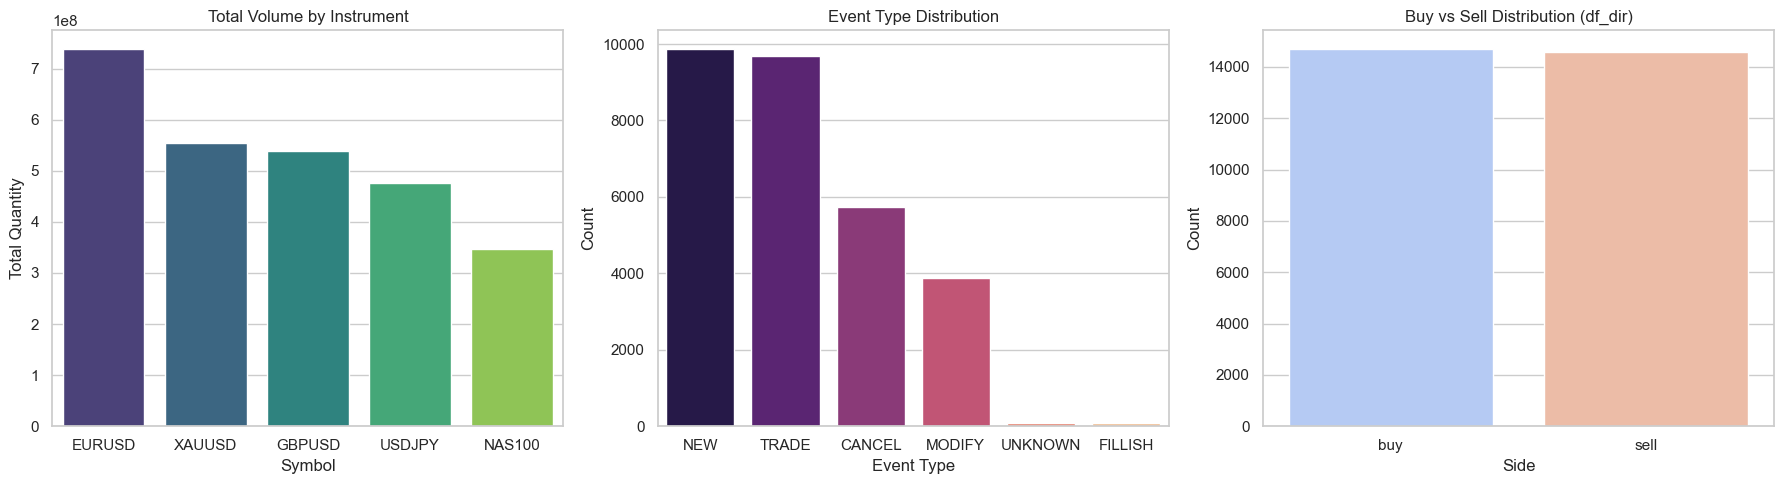


Summary Table: Activity by Instrument


,total_events,trades,total_volume,trade_share_%
sym,,,,
EURUSD,8729,2910,7.378996e+08,33.3
GBPUSD,5875,1954,5.395258e+08,33.3
NAS100,3819,1243,3.476227e+08,32.5
USDJPY,5058,1637,4.753431e+08,32.4
XAUUSD,5849,1946,5.534236e+08,33.3


In [49]:
# 2.2 MARKET ACTIVITY: Volume & Event Distribution

sns.set_theme(style="whitegrid")

# --- Volume by Symbol ---
volume_by_sym = (
    df_clean.groupby("sym")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

# --- Event Type Distribution ---
event_counts = df_clean["event_type"].value_counts()

# --- Side Distribution (df_dir only) ---
side_counts = df_dir["side"].value_counts()

# --- Summary Table ---
sym_stats = (
    df_clean.groupby("sym")
    .agg(
        total_events=("sym", "size"),
        trades=("event_type", lambda x: (x == "TRADE").sum()),
        total_volume=("quantity", "sum"),
    )
)
sym_stats["trade_share_%"] = (
    sym_stats["trades"] / sym_stats["total_events"] * 100
).round(1)

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x=volume_by_sym.index, y=volume_by_sym.values,
            hue=volume_by_sym.index, legend=False,
            ax=axes[0], palette="viridis")
axes[0].set_title("Total Volume by Instrument")
axes[0].set_ylabel("Total Quantity")
axes[0].set_xlabel("Symbol")

sns.barplot(x=event_counts.index, y=event_counts.values,
            hue=event_counts.index, legend=False,
            ax=axes[1], palette="magma")
axes[1].set_title("Event Type Distribution")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Event Type")

sns.barplot(x=side_counts.index, y=side_counts.values,
            hue=side_counts.index, legend=False,
            ax=axes[2], palette="coolwarm")
axes[2].set_title("Buy vs Sell Distribution (df_dir)")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("Side")

plt.tight_layout()
plt.show()

# --- Summary Table ---
print("\nSummary Table: Activity by Instrument")
display(sym_stats)

## 3. Abnormal Activity

Identify periods where behaviour deviates from typical patterns.

Define your own criteria for what constitutes abnormal activity and explain your approach.

Summarise your findings and comment on any patterns you observe.

## 4. Spread vs Price Dynamics

For each instrument, investigate the relationship between spread and subsequent price movements.

Define the relevant features and quantify the relationship using an appropriate method.

Comment on your findings.`

## 5. Trade Size Distribution

Analyse the distribution of trade sizes for each instrument.

Identify unusually large trades using a method of your choice and justify your approach.

Comment on the characteristics of the distribution.

## 6. Short-Horizon Prediction

Build a simple model to predict the direction of the next price move.

Describe:
- your feature construction
- how you split the data
- how you evaluate performance

Include a short discussion (100–200 words) covering:
- assumptions
- feature choices
- how your approach would scale to a much larger dataset